# Практическая работа 2 "Геометрические трансформации и специальные функции в библиотеке OpenCV"

1. Задание: Необходимо повторить весь код из примера с одним своим изображением, что означает, что все манипуляции должны быть произведены с одним изображением.

2. Прикрепить файл в формате .ipynb. 

3. Балл за задание: 3.

## Введение

В этой практической работе вы будете применять геометрические преобразования к изображению. Это позволит вам выполнять различные операции, такие как изменение формы, сдвигать, изменять форму и поворачивать изображение. А также как применять к изображению некоторые базовые операции с массивами и матрицами.

Загрузим изображение:

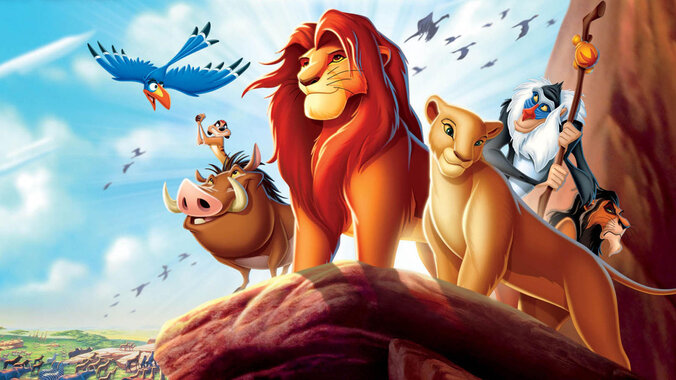

In [ ]:
from IPython.display import Image
Image("hp-cat.png")

Библиотечки:

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Определим вспомогательную функцию для построения двух изображений рядом друг с другом.

In [3]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

## Геометрические преобразования

Геометрические преобразования позволяют выполнять различные операции, например, сдвигать, изменять форму и поворачивать изображение.

### Масштабирование

Мы можем изменить размер изображения, используя для этой цели функцию `resize()` из модуля `cv2`. Вы можете указать коэффициент масштабирования или размер изображения:

Рассмотрим следующее изображение с соответствующими значениями интенсивности:

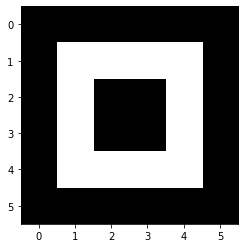

array([[  0.,   0.,   0.,   0.,   0.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.]])

In [4]:
toy_image = np.zeros((6,6))
toy_image[1:5,1:5]=255
toy_image[2:4,2:4]=0
plt.imshow(toy_image,cmap='gray')
plt.show()
toy_image

Мы можем изменить масштаб по определенной оси::

*   `fx`: масштабный коэффициент по горизонтальной оси
*   `fy`: масштабный коэффициент по вертикальной оси

Интерполяция параметров оценивает значения пикселей на основе соседних пикселей. <code>INTER_NEAREST</code> использует ближайший пиксель, а <code>INTER_CUBIC</code> использует несколько пикселей рядом со значением пикселя, которое мы хотели бы оценить.

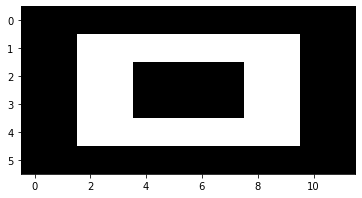

In [5]:
new_toy = cv2.resize(toy_image,None,fx=2, fy=1, interpolation = cv2.INTER_NEAREST )
plt.imshow(new_toy,cmap='gray')
plt.show()

Поэкспериментируем:

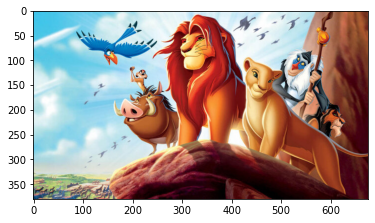

In [ ]:
image = cv2.imread("hp-cat.png")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

Мы можем масштабировать горизонтальную ось на два и оставить вертикальную ось как есть:

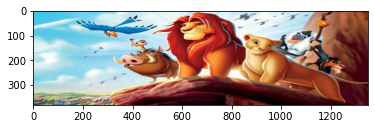

old image shape: (380, 676, 3) new image shape: (380, 1352, 3)


In [7]:
new_image = cv2.resize(image, None, fx=2, fy=1, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

Таким же образом мы можем масштабировать вертикальную ось на два:

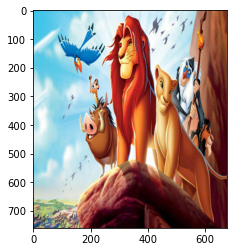

old image shape: (380, 676, 3) new image shape: (760, 676, 3)


In [8]:
new_image = cv2.resize(image, None, fx=1, fy=2, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

Мы можем масштабировать горизонтальную ось и вертикальную ось на два.

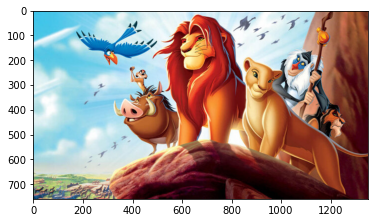

old image shape: (380, 676, 3) new image shape: (760, 1352, 3)


In [9]:
new_image = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

Мы также можем уменьшить изображение, установив коэффициент масштабирования на действительное число от 0 до 1:

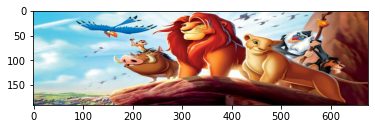

old image shape: (380, 676, 3) new image shape: (190, 676, 3)


In [10]:
new_image = cv2.resize(image, None, fx=1, fy=0.5, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

Мы также можем указать количество строк и столбцов:

In [11]:
rows = 100
cols = 200

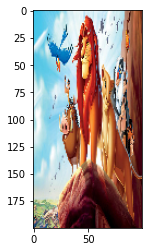

old image shape: (380, 676, 3) new image shape: (200, 100, 3)


In [12]:
new_image = cv2.resize(image, (100, 200), interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()
print("old image shape:", image.shape, "new image shape:", new_image.shape)

### Translation (сдвиг/смещение)

Сдвиг/смещение — это когда вы меняете расположение изображения. <code>tx</code> — это количество пикселей, на которое вы смещаете местоположение в горизонтальном направлении, а <code>ty</code> — это количество пикселей, которое вы смещаете в вертикальном направлении. Вы можете создать матрицу преобразования $M$ для сдвига изображения.

В этом примере мы сдвигаем изображение на 100 пикселей по горизонтали:

In [13]:
tx = 100
ty = 0
M = np.float32([[1, 0, tx], [0, 1, ty]])
M

array([[  1.,   0., 100.],
       [  0.,   1.,   0.]], dtype=float32)

Форма изображения определяется:

In [14]:
rows, cols, _ = image.shape

Мы используем функцию <code>warpAffine</code> из модуля <code>cv2</code>. Первый входной параметр — массив изображений, второй входной параметр — матрица преобразования <code>M</code>, а последний входной параметр — длина и ширина выходного изображения $(cols,rows)$:

In [15]:
new_image = cv2.warpAffine(image, M, (cols, rows))

Мы можем построить изображение; части изображения, которые не имеют никакой интенсивности, устанавливаются равными нулю:

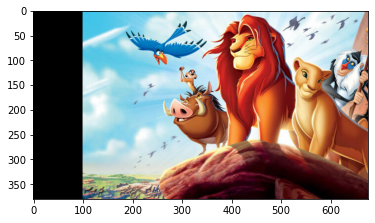

In [16]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

Мы видим, что часть исходного изображения была обрезана. Мы можем исправить это, изменив размер выходного изображения: <code>(cols + tx,rows + ty)</code>:

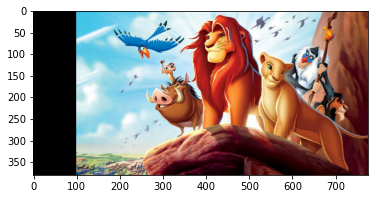

In [17]:
new_image = cv2.warpAffine(image, M, (cols + tx, rows + ty))
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

Мы можем сдвинуть изображение по горизонтали:

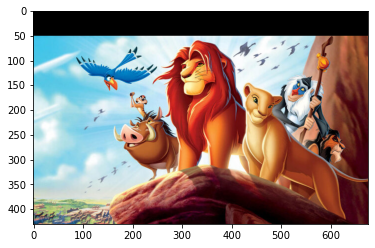

In [18]:
tx = 0
ty = 50
M = np.float32([[1, 0, tx], [0, 1, ty]])
new_iamge = cv2.warpAffine(image, M, (cols + tx, rows + ty))
plt.imshow(cv2.cvtColor(new_iamge, cv2.COLOR_BGR2RGB))
plt.show()

### Вращение

Мы можем повернуть изображение на угол θ, что достигается матрицей вращения <code>getRotationMatrix2D</code>.

<p><code>center</code>: центр вращения исходного изображения. Мы будем использовать только центр изображения.</p>
<p><code>угол</code>: угол поворота в градусах. Положительные значения означают вращение против часовой стрелки (предполагается, что начало координат находится в верхнем левом углу).</p>
<p><code>масштаб</code>: Изотропный коэффициент масштабирования, в этом курсе значение будет равно единице.</p>

Мы можем повернуть наше изображение игрушки на 45 градусов:

In [20]:
theta = 45.0
M = cv2.getRotationMatrix2D(center=(3, 3), angle=theta, scale=1)
new_toy_image = cv2.warpAffine(toy_image, M, (6, 6))

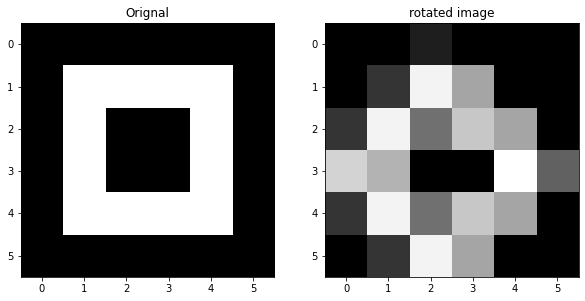

In [21]:
plot_image(toy_image, new_toy_image, title_1="Orignal", title_2="rotated image")

Глядя на значения интенсивности, мы видим, что многие значения были интерполированы:

In [22]:
new_toy_image

array([[  0.        ,   0.        ,  28.38867188,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [195.234375  , 165.10253906,   0.        ,   0.        ,
        234.82910156,  89.89746094],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ]])

Мы можем выполнить ту же операцию с цветными изображениями:

In [23]:
cols, rows, _ = image.shape

In [24]:
M = cv2.getRotationMatrix2D(center=(cols // 2 - 1, rows // 2 - 1), angle=theta, scale=1)
new_image = cv2.warpAffine(image, M, (cols, rows))

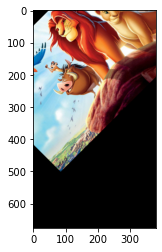

In [25]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

## Математические операции

### Операции с массивами

Мы можем выполнять операции с массивами над изображением, используя вещание, мы можем добавить константу к значению интенсивности каждого пикселя.

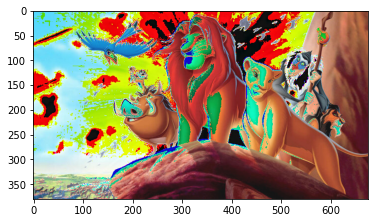

In [26]:
new_image = image + 20

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

Мы также можем умножить значение интенсивности каждого пикселя на постоянное значение.

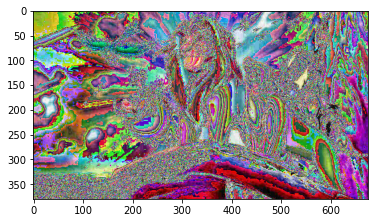

In [27]:
new_image = 10 * image
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

Мы можем сложить элементы двух массивов одинаковой формы. В этом примере мы генерируем массив случайных шумов той же формы и типа данных, что и наше изображение.

In [28]:
Noise = np.random.normal(0, 20, (cols, rows,  3)).astype(np.uint8)
Noise.shape

(380, 676, 3)

Мы добавляем сгенерированный шум к изображению и строим результат. Мы видим значения, которые испортили изображение:

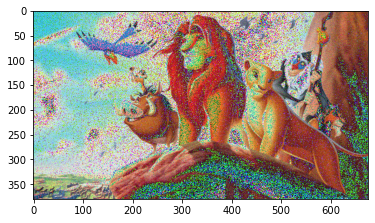

In [29]:
new_image = image + Noise

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

При этом мы можем перемножать элементы двух массивов одинаковой формы. Мы можем умножить случайное изображение и 1 изображение и построить результат.

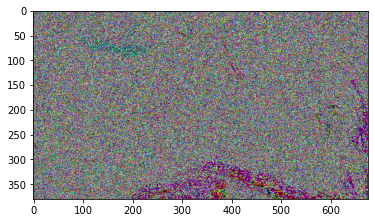

In [30]:
new_image = image*Noise

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.show()

### Матричные операции

Изображения в градациях серого являются матрицами. Рассмотрим следующее изображение в градациях серого:

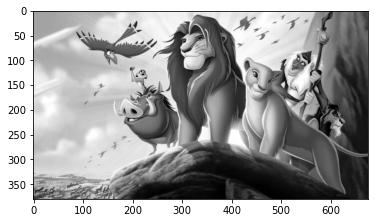

In [ ]:
im_gray = cv2.imread('hp-cat.png', cv2.IMREAD_GRAYSCALE)
im_gray.shape

plt.imshow(im_gray,cmap='gray')
plt.show()

Мы можем применять алгоритмы, разработанные для матриц. Мы можем использовать разложение по сингулярным значениям, разлагая нашу матрицу изображения на произведение трех матриц.

In [32]:
U, s, V = np.linalg.svd(im_gray , full_matrices=True)

Мы видим, что <code>s</code> не прямоугольный:

In [33]:
s.shape

(380,)

Мы можем преобразовать <code>s</code> в диагональную матрицу <code>S</code>:

In [34]:
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))
S[:image.shape[0], :image.shape[0]] = np.diag(s)

Мы можем построить матрицу `U` и `V`:

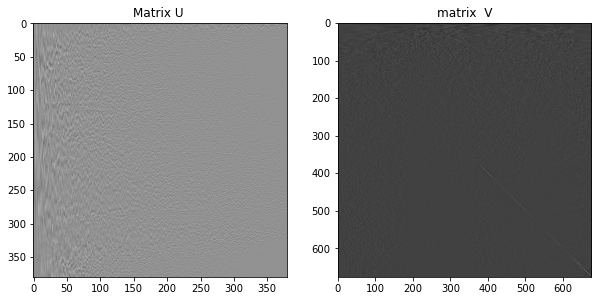

In [36]:
plot_image(U,V,title_1="Matrix U ",title_2="matrix  V")

Мы видим, что большинство элементов в `S` равны нулю:

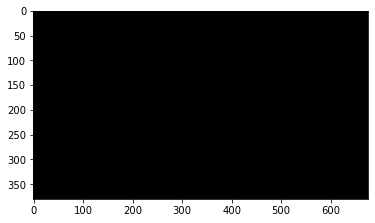

In [37]:
plt.imshow(S,cmap='gray')
plt.show()

Мы можем найти матричное произведение всех матриц. Во-первых, мы можем выполнить матричное умножение на `S` и `U` и присвоить его `B` и построить результаты:

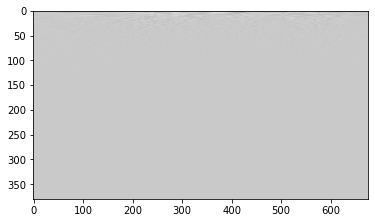

In [38]:
B = S.dot(V)
plt.imshow(B,cmap='gray')
plt.show()

Мы можем найти матричное произведение `U`, `S` и `B`. Мы видим, что это все изображение:

In [39]:
A = U.dot(B)

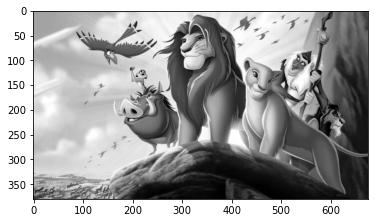

In [40]:
plt.imshow(A,cmap='gray')
plt.show()

Оказывается, многие элементы избыточны, поэтому мы можем удалить некоторые строки и столбцы `S` и `V` и аппроксимировать изображение, найдя произведение.

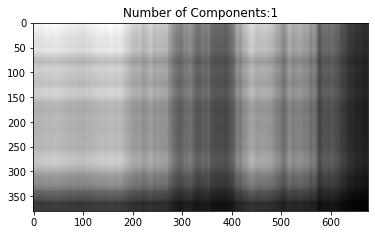

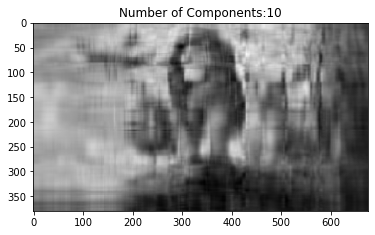

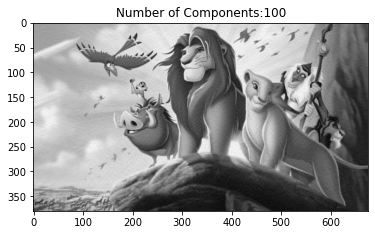

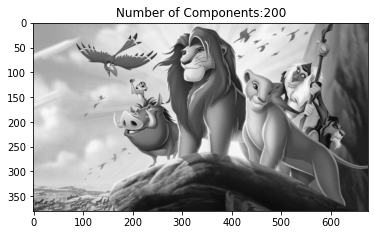

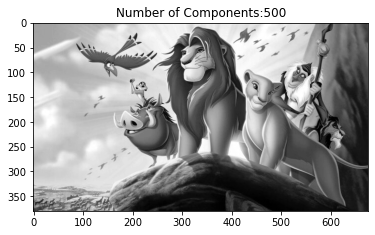

In [41]:
for n_component in [1,10,100,200, 500]:
    S_new = S[:, :n_component]
    V_new = V[:n_component, :]
    A = U.dot(S_new.dot(V_new))
    plt.imshow(A,cmap='gray')
    plt.title("Number of Components:"+str(n_component))
    plt.show()

Мы видим, что нам нужно всего от 100 до 200 компонентов для представления изображения.

## Геометрические операции и другие математические инструменты с OpenCV

Пространственные операции используют соседние пиксели для определения текущего значения пикселя. Приложения включают фильтрацию и повышение резкости. Они используются на многих этапах компьютерного зрения, таких как сегментация, и являются ключевым строительным блоком в алгоритмах искусственного интеллекта.

Загрузим изображение:

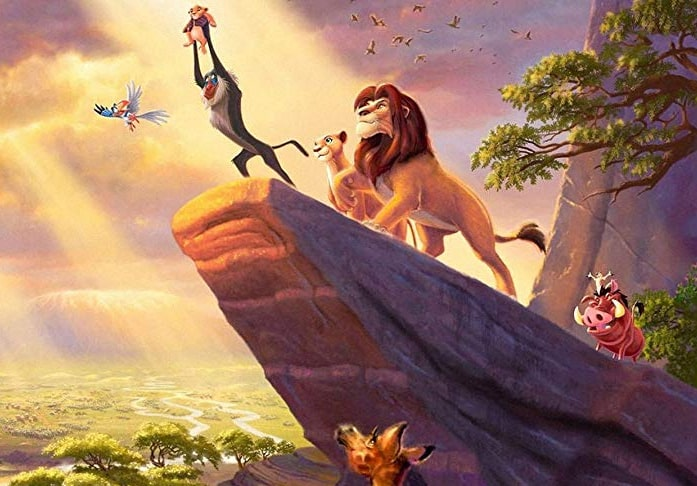

In [ ]:
from IPython.display import Image
Image("hp-cat.png")

Библиотечки:

In [43]:
# Used to view the images
import matplotlib.pyplot as plt
# Used to perform filtering on an image
import cv2
# Used to create kernels for filtering
import numpy as np

Функция для отображения двух изображения рядом:

In [44]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))
    plt.title(title_2)
    plt.show()

## Линейная фильтрация

Фильтрация включает улучшение изображения, например, удаление шума из изображения. Шум вызван плохой камерой или плохим сжатием изображения. Те же самые факторы, которые вызывают шум, могут привести к размытию изображений. Мы можем применять фильтры для повышения резкости этих изображений. Свертка — это стандартный способ фильтрации изображения. Фильтр называется ядром, и разные ядра выполняют разные задачи. Свертка используется для многих самых передовых алгоритмов искусственного интеллекта. Мы просто берем скалярное произведение ядра и часть изображения одинакового размера. Затем мы сдвигаем ядро и повторяем.

Рассмотрим следующее изображение:

[[[130 126 175]
  [132 126 173]
  [132 126 173]
  ...
  [ 78 104 116]
  [ 67  93 105]
  [ 53  79  91]]

 [[130 126 175]
  [133 127 174]
  [132 126 173]
  ...
  [ 53  81  92]
  [ 47  75  86]
  [ 41  69  80]]

 [[132 126 175]
  [132 126 173]
  [133 125 172]
  ...
  [ 27  57  68]
  [ 29  59  70]
  [ 25  55  66]]

 ...

 [[146 218 248]
  [146 216 246]
  [151 221 250]
  ...
  [ 34  18  41]
  [ 36  20  43]
  [ 40  21  46]]

 [[165 229 253]
  [162 227 248]
  [167 230 251]
  ...
  [ 31  15  38]
  [ 33  17  40]
  [ 38  20  43]]

 [[171 233 251]
  [171 230 249]
  [173 232 248]
  ...
  [ 32  17  38]
  [ 33  17  40]
  [ 40  22  45]]]


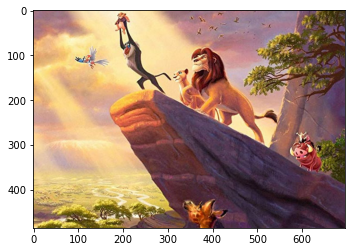

In [ ]:
# Loads the image from the specified file
image = cv2.imread("hp-cat.png")
print(image)
# Converts the order of the color from BGR (Blue Green Red) to RGB (Red Green Blue) then renders the image from the array of data
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

Изображения, с которыми мы работаем, состоят из значений RGB, которые представляют собой значения от 0 до 255. Ноль означает белый шум, из-за этого изображение выглядит зернистым:

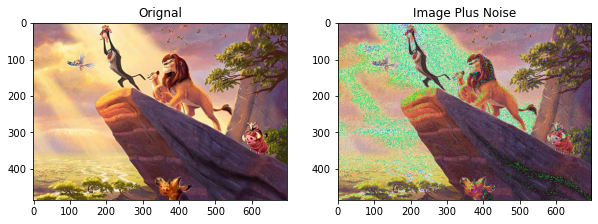

In [46]:
# Get the number of rows and columns in the image
rows, cols,_= image.shape
# Creates values using a normal distribution with a mean of 0 and standard deviation of 15, the values are converted to unit8 which means the values are between 0 and 255
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Add the noise to the image
noisy_image = image + noise
# Plots the original image and the image with noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal",title_2="Image Plus Noise")

При добавлении шума к изображению иногда значение может быть больше 255, в этом случае 256 вычитается из значения, чтобы обернуть число вокруг, сохраняя его между 0 и 255. Например, рассмотрим изображение со значением RGB 137. Мы добавляем шум со значением RGB 215 и получаем значение RGB 352. Затем мы вычитаем 256, общее количество возможных значений от 0 до 255, чтобы получить число от 0 до 255.

### Фильтрация шума

Сглаживающие фильтры усредняют пиксели в окрестности, их иногда называют фильтрами нижних частот. Для средней фильтрации ядро просто усредняет ядра в окрестности.

In [48]:
# Создаем ядро, представляющее собой массив 6 на 6, где каждое значение равно 1/36.
kernel = np.ones((6,6))/36

Функция <code>filter2D</code> выполняет 2D-свертку между изображением <code>src</code> и <code>kernel</code> для каждого цветового канала независимо. Параметр <a href="https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkCV0101ENCoursera25797139-2021-01-01#filter_depths">ddepth</a> имеет отношение к размеру выходного изображения, мы установим его равным -1, чтобы вход и выход имели одинаковый размер.

In [49]:
# Фильтруем изображения с помощью ядра
image_filtered = cv2.filter2D(src=noisy_image, ddepth=-1, kernel=kernel)

Мы можем построить изображение до и после фильтрации; мы видим, что шум уменьшился, но изображение размыто:

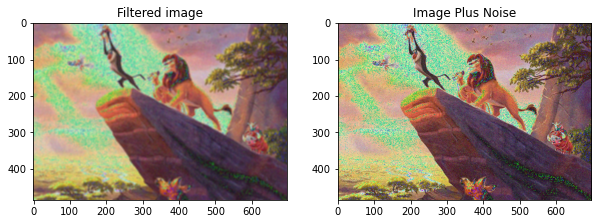

In [51]:
# Построим отфильтрованное изображение и изображение с шумом, используя функцию, определенную вверху.
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Ядро меньшего размера сохраняет резкость изображения, но фильтрует меньше шума, здесь мы пробуем ядро 4x4.

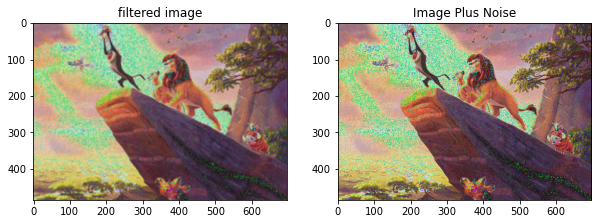

In [52]:
# Creates a kernel which is a 4 by 4 array where each value is 1/16
kernel = np.ones((4,4))/16
# Filters the images using the kernel
image_filtered=cv2.filter2D(src=noisy_image,ddepth=-1,kernel=kernel)
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered , noisy_image,title_1="filtered image",title_2="Image Plus Noise")

### Размытие по Гауссу

Функция <code>GaussianBlur</code> сворачивает исходное изображение с указанным ядром Гаусса. Она фильтрует шум, но лучше сохраняет края. Он имеет следующие параметры:

Parameters

<p><code>src</code> входное изображение; изображение может иметь любое количество каналов, которые обрабатываются независимо</p>
<p><code>ksize:</code> Гауссовский размер ядра</p>
<p><code>sigmaX</code> Стандартное отклонение ядра Гаусса в направлении X</p>
<p><code>sigmaY</code> Стандартное отклонение ядра Гаусса в направлении Y; если sigmaY равно нулю, оно устанавливается равным sigmaX

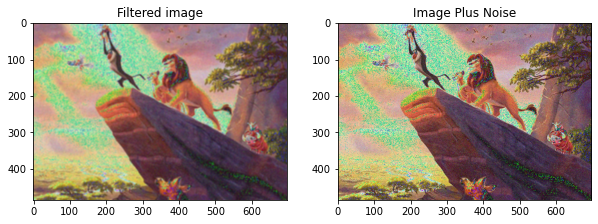

In [53]:
# Filters the images using GaussianBlur on the image with noise using a 4 by 4 kernel 
image_filtered = cv2.GaussianBlur(noisy_image,(5,5),sigmaX=4,sigmaY=4)
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Сигма ведет себя как размер среднего фильтра, большее значение сигмы сделает изображение размытым, но вы все еще ограничены размером фильтра, здесь мы устанавливаем сигму на 10

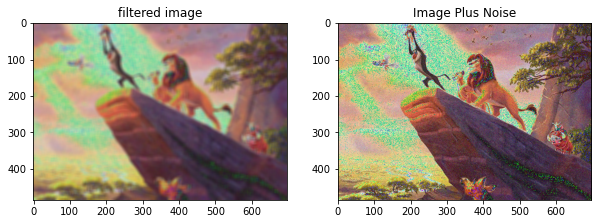

In [54]:
# Filters the images using GaussianBlur on the image with noise using a 11 by 11 kernel 
image_filtered = cv2.GaussianBlur(noisy_image,(11,11),sigmaX=10,sigmaY=10)
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="filtered image",title_2="Image Plus Noise")

Посмотрите, что происходит, когда вы устанавливаете разные значения sigmaX, sigmaY и/или используете неквадратные ядра.

### Повышение резкости изображения

Повышение резкости изображения включает в себя сглаживание изображения и вычисление производных. Мы можем повысить резкость изображения, применив следующее ядро.

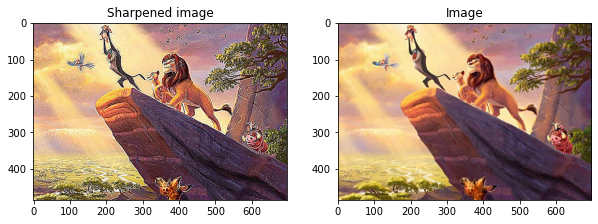

In [55]:
# Common Kernel for image sharpening
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1],
                   [-1,-1,-1]])
# Applys the sharpening filter using kernel on the original image without noise
sharpened = cv2.filter2D(image, -1, kernel)
# Plots the sharpened image and the original image without noise
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image")

### Края (Edges)

Края — это места, где меняется интенсивность пикселей. Градиент функции выводит скорость изменения. Можно аппроксимировать градиент изображения в градациях серого с помощью свертки. Существует несколько методов аппроксимации градиента, давайте воспользуемся детектором границ Собеля. Это объединяет несколько сверток и нахождение величины результата. Рассмотрим следующее изображение:

[[141 141 141 ... 105  94  80]
 [141 142 141 ...  81  75  69]
 [141 141 140 ...  57  59  55]
 ...
 [219 217 222 ...  27  29  31]
 [229 226 229 ...  24  26  29]
 [231 229 230 ...  25  26  31]]


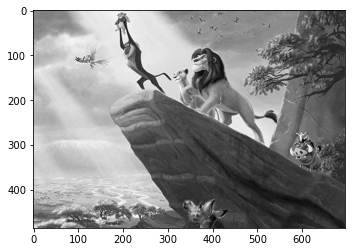

In [ ]:
# Loads the image from the specified file
img_gray = cv2.imread('hp-cat.png', cv2.IMREAD_GRAYSCALE)
print(img_gray)
# Renders the image from the array of data, notice how it is 2 diemensional instead of 3 diemensional because it has no color
plt.imshow(img_gray ,cmap='gray')

Мы сглаживаем изображение, это уменьшает изменения, которые могут быть вызваны шумом, влияющим на градиент.

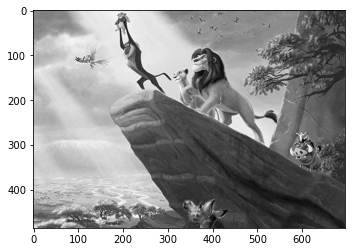

In [57]:
# Filters the images using GaussianBlur on the image with noise using a 3 by 3 kernel 
img_gray = cv2.GaussianBlur(img_gray,(3,3),sigmaX=0.1,sigmaY=0.1)
# Renders the filtered image
plt.imshow(img_gray ,cmap='gray')

Мы можем аппроксимировать производную в направлении X или Y, используя функцию <code>Sobel</code>, вот параметры:

<p><code>src</code>: входное изображение</p>
<p><code>ddepth</code>: глубина вывода изображения; в случае 8-битных входных изображений это приведет к усеченным производным</p>
<p><code>dx</code>: порядок производной x</p>
<p><code>dx</code>: порядок производной y</p>
<p><code>ksize</code> размер расширенного ядра Sobel; должно быть 1, 3, 5 или 7</p>

dx = 1 представляет собой производную по оси x. Функция аппроксимирует производную путем свертки изображения со следующим ядром

\begin{bmatrix}
1 & 0 & -1 \\\\
2 & 0 & -2 \\\\
1 & 0 & -1
\end{bmatrix}

Мы можем применить функцию:

In [59]:
ddepth = cv2.CV_16S
# Applys the filter on the image in the X direction
grad_x = cv2.Sobel(src=img_gray, ddepth=ddepth, dx=1, dy=0, ksize=3)

Мы можем построить результат

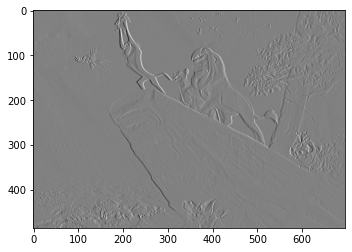

In [60]:
plt.imshow(grad_x,cmap='gray')

dy=1 представляет собой производную в направлении y. Функция аппроксимирует производную путем свертки изображения со следующим ядром

\begin{bmatrix}
\ \ 1 & \ \ 2 & \ \ 1 \\\\
\ \ 0 & \ \ 0 & \ \ 0 \\\\
-1 & -2 & -1
\end{bmatrix}

Мы можем применить функцию и построить график результата

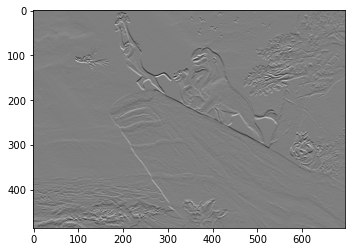

In [61]:
# Applys the filter on the image in the X direction
grad_y = cv2.Sobel(src=img_gray, ddepth=ddepth, dx=0, dy=1, ksize=3)
plt.imshow(grad_y,cmap='gray')

Мы можем аппроксимировать градиент, вычислив абсолютные значения и преобразовав результат в 8-битный:

In [62]:
# Converts the values back to a number between 0 and 255
abs_grad_x = cv2.convertScaleAbs(grad_x)
abs_grad_y = cv2.convertScaleAbs(grad_y)

Затем примените функцию <code>addWeighted</code> для вычисления суммы двух массивов следующим образом:

In [63]:
# Adds the derivative in the X and Y direction
grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

Затем мы наносим результаты на график, мы видим, что изображение с линиями имеет значения высокой интенсивности, представляющие большой градиент.

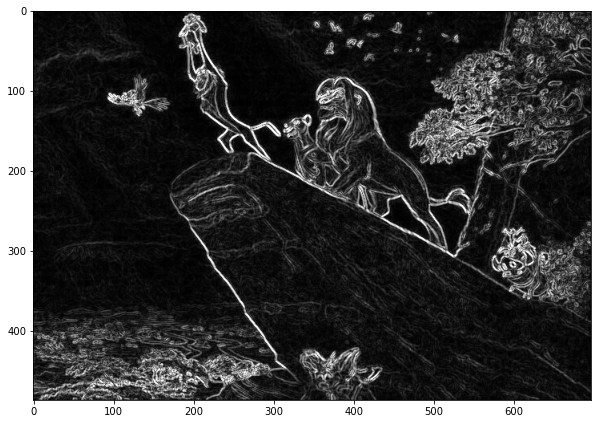

In [64]:
# Make the figure bigger and renders the image
plt.figure(figsize=(10,10))
plt.imshow(grad,cmap='gray')

### Медиана

Медианные фильтры находят медиану всех пикселей под областью ядра, и центральный элемент заменяется этим медианным значением.

Мы можем применять медианные фильтры к обычным изображениям, но давайте посмотрим, как мы можем использовать медианные фильтры для улучшения сегментации.

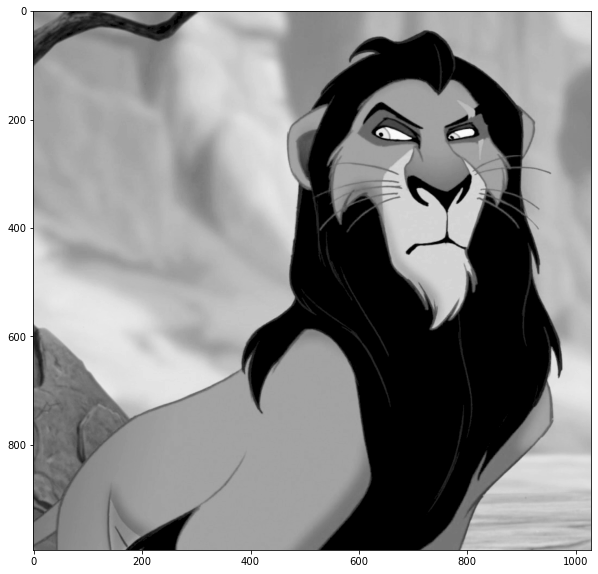

In [ ]:
# Load the camera man image
image = cv2.imread("hp-cat.png",cv2.IMREAD_GRAYSCALE)
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")

Теперь давайте применим медианный фильтр с помощью функции `medianBlur`. Параметры этой функции: `src`: изображение и `ksize`: размер ядра.

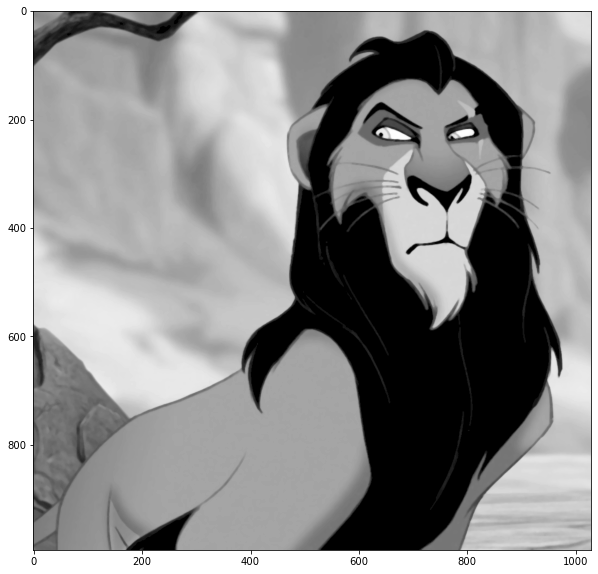

In [66]:
# Filter the image using Median Blur with a kernel of size 5
filtered_image = cv2.medianBlur(image, 5)
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(filtered_image,cmap="gray")

### Параметры пороговой функции

`src`: изображение для использования

`thresh`: порог

`maxval`: максимальное значение для использования

`type`: Тип фильтрации
<p>Пороговая функция работает, просматривая значение оттенков серого каждого пикселя и присваивая значение, если оно ниже порога, и другое значение, если оно выше порога. В нашем примере порог равен 0 (черный), а тип — двоичный инверсный, поэтому, если значение выше порога, присвоенное значение равно 0 (черный), а если оно ниже или равно порогу, используется maxval 255 (белый). Таким образом, если пиксель 0 черный, ему назначается 255 (белый), а если пиксель не черный, то он назначается черным, что <code>THRESH_BINARY_INV</code> сообщает <code>OpenCV</code>. Вот как это будет работать без <code>THRESH_OTSU</code>.
<p>Поскольку мы используем <code>THRESH_OTSU</code>, это означает, что <code>OpenCV</code> определит оптимальный порог.

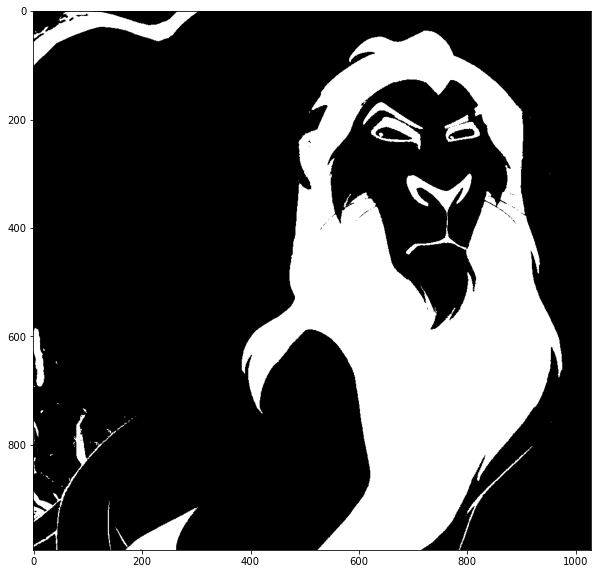

In [67]:
# Returns ret which is the threshold used and outs which is the image
ret, outs = cv2.threshold(src = image, thresh = 0, maxval = 255, type = cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)

# Make the image larger when it renders
plt.figure(figsize=(10,10))

# Render the image
plt.imshow(outs, cmap='gray')